<a href="https://colab.research.google.com/github/Lee-Minsoo-97/Sales-Data-Prediction/blob/gemini_original/iHerb_Sales_Pred_ML_Project_v1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# iHerb 판매량 예측 머신러닝 프로젝트
> **최종 목표:** 과거 판매 데이터와 PO(Purchase Order) 데이터를 기반으로, 미래의 SKU별 월간 판매량을 예측하는 머신러닝 모델을 구축합니다.

---
### **1단계: 데이터 준비 및 통합 (Data Preparation)**
1.  **데이터 로딩:** 흩어져 있는 월별 판매 데이터(Sales Data)와 통합된 PO 데이터를 각각 불러옵니다.
2.  **데이터 클리닝:** 데이터 타입을 올바르게 변환하고, 불필요한 데이터(예: UPC Code가 0인 항목)를 제거하여 데이터의 품질을 높입니다.
3.  **데이터 통합:** 월별 판매 데이터와 월별로 집계한 PO 데이터를 SKU와 날짜를 기준으로 하나의 마스터 데이터프레임으로 통합합니다.

---
### **2단계: 피처 엔지니어링 (Feature Engineering)**
모델이 과거의 패턴을 학습할 수 있도록, 원본 데이터를 기반으로 예측에 도움이 될 새로운 '힌트(피처)'들을 생성합니다.
* **시간 기반 피처:** 연도, 월, 분기 등 시간의 흐름에 따른 정보를 추가합니다.
* **시차 피처 (Lag Features):** 1~3개월 전의 과거 판매량과 PO 수량을 현재 데이터 행에 추가하여, 과거의 추세와 계획이 현재에 미치는 영향을 학습시킵니다.
* **이동 평균 피처 (Rolling Features):** 최근 3개월간의 평균 판매량 등을 계산하여, 단기적인 변동성을 완화하고 전반적인 트렌드를 포착합니다.
* **범주형 피처 변환:** 'Brand Code'나 'Status'와 같은 문자 데이터를 모델이 이해할 수 있는 숫자(0/1) 형식으로 변환합니다. (원-핫 인코딩)

---
### **3단계: 모델 훈련 (Model Training)**
1.  **데이터 분리:** 전체 데이터를 시간 순서에 따라 과거의 **훈련(Train) 데이터**와 미래의 **테스트(Test) 데이터**로 분리합니다.
2.  **기준 모델 선정:** 빠르고 강력한 **LightGBM** 모델을 첫 번째 기준(Baseline) 모델로 선택합니다.
3.  **모델 학습:** 준비된 훈련 데이터를 사용하여 LightGBM 모델을 학습시킵니다.

---
### **4단계: 평가 및 분석 (Evaluation & Analysis)**
1.  **예측 수행:** 훈련된 모델을 사용하여, 본 적 없는 테스트 데이터의 판매량을 예측합니다.
2.  **성능 평가:** 예측값과 실제값을 비교하여 모델의 평균 오차(**MAE**)를 계산하고, 모델의 전반적인 정확도를 평가합니다.
3.  **결과 분석:** 모델이 어떤 피처를 중요하게 생각하는지(**Feature Importance**)를 분석하여 비즈니스 인사이트를 도출하고, 예측이 크게 빗나간 경우를 분석하여 모델의 약점을 파악합니다.

---
### **5단계: 모델 고도화 (Future Steps)**
* **하이퍼파라미터 튜닝:** 모델의 내부 설정값을 정밀하게 조정하여 성능을 최적화합니다.
* **모델 추가 실험:** XGBoost 등 다른 모델을 테스트하고 성능을 비교합니다.
* **앙상블 (Ensemble):** 여러 모델의 예측을 결합하여 예측 안정성과 정확도를 극대화합니다.
* **피처 추가:** 필요시, `Product Description`의 텍스트 정보나 프로모션과 같은 외부 데이터를 추가하여 성능을 더욱 향상시킵니다.



<br />
<br />
<br />
<br />


  
    


## 1단계: 모델링용 데이터 불러오기

<br />

In [ ]:
import pandas as pd

# Google Drive를 마운트합니다.
from google.colab import drive
drive.mount('/content/drive')

# 저장했던 최종 데이터 파일 경로
file_path = '/content/drive/MyDrive/Colab Notebooks/Data for Modeling/df_for_modeling.csv'

# CSV 파일을 데이터프레임으로 불러오기
# parse_dates=['Date'] 옵션으로 'Date' 컬럼을 날짜 타입으로 자동 변환합니다.
df_model = pd.read_csv(file_path, parse_dates=['Date'])

print("✅ 모델링용 데이터를 성공적으로 불러왔습니다.")
print("\n--- 불러온 데이터 정보 ---")
df_model.info()

print("\n--- 불러온 데이터 샘플 ---")
print(df_model.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 모델링용 데이터를 성공적으로 불러왔습니다.

--- 불러온 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4645 entries, 0 to 4644
Data columns (total 37 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   SKU                         4645 non-null   object        
 1   UPC Code                    4645 non-null   int64         
 2   Product Description         4645 non-null   object        
 3   Sales                       4645 non-null   int64         
 4   Date                        4645 non-null   datetime64[ns]
 5   PO_Quantity                 4645 non-null   float64       
 6   sales_lag_1                 4645 non-null   float64       
 7   po_quantity_lag_1           4645 non-null   float64       
 8   sales_lag_2                 4645 non-null   float64       
 9   po_quanti

## 2 & 3단계: 데이터 분리 및 모델 훈련

<br />

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

# --- 2. 훈련용/테스트용 데이터 분리 ---
# 마지막 2개월(2025년 7-8월)을 테스트용 데이터로 분리합니다.
test_start_date = '2025-07-01'
train_df = df_model[df_model['Date'] < test_start_date]
test_df = df_model[df_model['Date'] >= test_start_date]

# --- 3. 훈련을 위한 데이터 준비 (X, y 분리) ---
# 예측 목표(Target)인 'Sales'를 y로 지정합니다.
# 'Sales'와 모델에 필요 없는 식별자 컬럼들을 제외한 나머지를 피처(X)로 지정합니다.
cols_to_drop = ['Date', 'SKU', 'UPC Code', 'Product Description', 'Sales']

X_train = train_df.drop(columns=cols_to_drop)
y_train = train_df['Sales']
X_test = test_df.drop(columns=cols_to_drop)
y_test = test_df['Sales']

print(f"✅ 훈련 준비 완료: {len(X_train.columns)}개의 피처를 사용합니다.")

# --- 4. LightGBM 모델 훈련 및 예측 ---
print("\n🚀 모델 훈련을 시작합니다...")
lgbm = lgb.LGBMRegressor(random_state=42)
lgbm.fit(X_train, y_train)
print("✅ 모델 훈련이 완료되었습니다.")

# 학습된 모델로 테스트 데이터의 판매량 예측
predictions = lgbm.predict(X_test)

# --- 5. 성능 평가 ---
# 평균 절대 오차 (MAE) 계산
mae = mean_absolute_error(y_test, predictions)
print("\n--- 모델 예측 성능 ---")
print(f"평균 절대 오차 (MAE): {mae:.2f}")

# 예측 결과와 실제값을 비교하기 위해 데이터프레임으로 확인
results_df = pd.DataFrame({
    'Date': test_df['Date'],
    'SKU': test_df['SKU'],
    'Actual_Sales': y_test,
    'Predicted_Sales': predictions
})

print("\n--- 실제값 vs 예측값 샘플 ---")
print(results_df.head())

✅ 훈련 준비 완료: 32개의 피처를 사용합니다.

🚀 모델 훈련을 시작합니다...
✅ 모델 훈련이 완료되었습니다.

--- 모델 예측 성능 ---
평균 절대 오차 (MAE): 37.87

--- 실제값 vs 예측값 샘플 ---
         Date       SKU  Actual_Sales  Predicted_Sales
12 2025-07-01  APB68267           949      1291.899638
13 2025-08-01  APB68267          1130      1396.512843
26 2025-07-01  APB68268          1233      1572.605434
27 2025-08-01  APB68268          1164      1405.747624
47 2025-07-01  APB68270           435      1347.277910


In [ ]:
results_df.head(10)

,Date,SKU,Actual_Sales,Predicted_Sales
12,2025-07-01,APB68267,949,1291.899638
13,2025-08-01,APB68267,1130,1396.512843
26,2025-07-01,APB68268,1233,1572.605434
27,2025-08-01,APB68268,1164,1405.747624
47,2025-07-01,APB68270,435,1347.277910
48,2025-08-01,APB68270,337,1098.519487
61,2025-07-01,APB68271,301,376.871404
62,2025-08-01,APB68271,315,415.585959
75,2025-07-01,APB68272,417,306.357335
76,2025-08-01,APB68272,362,412.594801


1. 피처 중요도(Feature Importance) 확인

<Figure size 1000x1000 with 0 Axes>

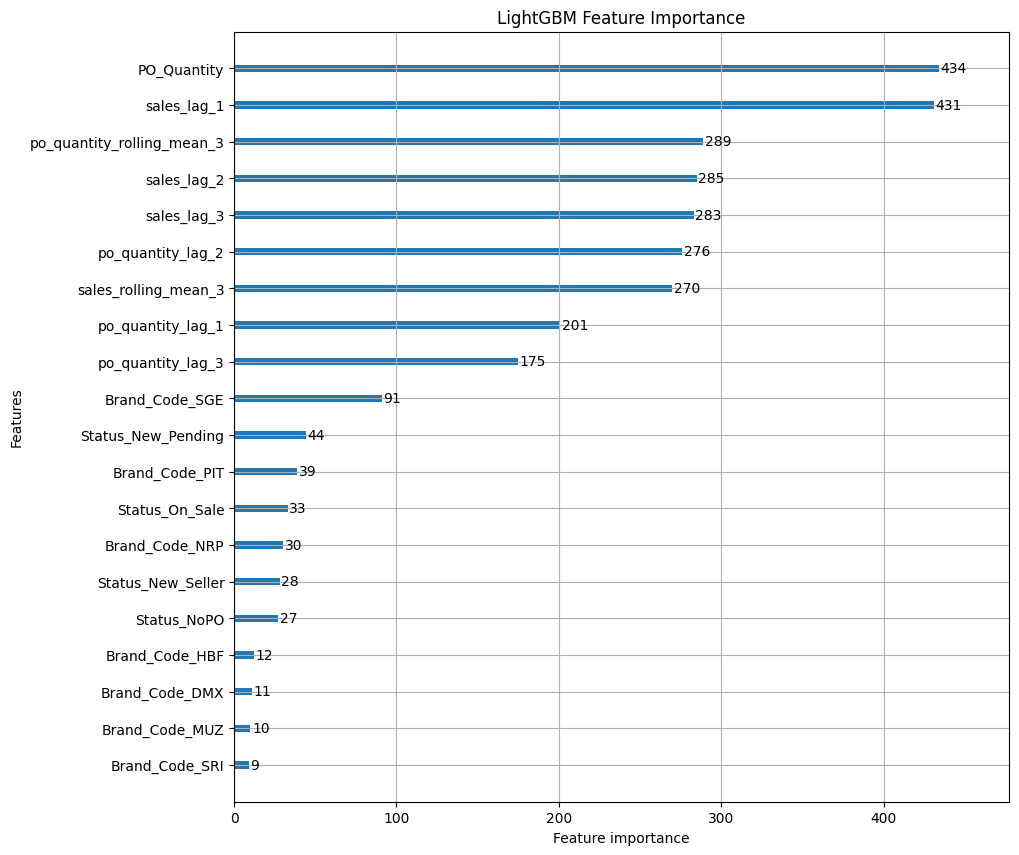

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 피처 중요도 상위 20개 시각화
plt.figure(figsize=(10, 10))
lgb.plot_importance(lgbm, max_num_features=20, figsize=(10,10))
plt.title('LightGBM Feature Importance')
plt.show()

2. 오차 분석(Error Analysis)

In [ ]:
# results_df에 오차(Error) 및 오차율(%) 컬럼 추가
results_df['Error'] = results_df['Actual_Sales'] - results_df['Predicted_Sales']
results_df['Error_abs'] = abs(results_df['Error'])

# 오차가 가장 컸던 Top 10 SKU 확인
print("\n--- 예측 오차가 가장 컸던 Top 10 ---")
print(results_df.sort_values(by='Error_abs', ascending=False).head(10))


--- 예측 오차가 가장 컸던 Top 10 ---
           Date       SKU  Actual_Sales  Predicted_Sales        Error  \
3370 2025-07-01  NRP48814          3850      2632.970590  1217.029410   
1290 2025-08-01  EQQ45647           391      1456.141591 -1065.141591   
1493 2025-07-01  HBF94449           102      1146.843609 -1044.843609   
4200 2025-07-01  SGE56360           100      1131.485657 -1031.485657   
103  2025-07-01  APB68274          3157      2242.286413   914.713587   
47   2025-07-01  APB68270           435      1347.277910  -912.277910   
3371 2025-08-01  NRP48814          1748      2632.970590  -884.970590   
48   2025-08-01  APB68270           337      1098.519487  -761.519487   
1294 2025-08-01  EQQ45648           440      1042.200664  -602.200664   
132  2025-08-01  APB68276          1591      1002.262435   588.737565   

        Error_abs  
3370  1217.029410  
1290  1065.141591  
1493  1044.843609  
4200  1031.485657  
103    914.713587  
47     912.277910  
3371   884.970590  
48     

## 다음 단계: 하이퍼파라미터 튜닝 실행

In [ ]:
# Optuna 라이브러리가 설치되어 있지 않다면 설치합니다.
!pip install optuna

import optuna
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

def objective(trial):
    # 튜닝할 하이퍼파라미터들의 탐색 범위를 지정합니다.
    params = {
        'objective': 'regression_l1', # MAE를 기준으로 최적화
        'metric': 'mae',
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1  # 모든 CPU 코어를 사용하여 속도 향상
    }

    # 모델 생성 및 훈련
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)

    # 예측 및 성능 평가
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    return mae

# Optuna를 사용하여 최적의 하이퍼파라미터 탐색 시작
print("🚀 하이퍼파라미터 튜닝을 시작합니다... (약간의 시간이 소요될 수 있습니다)")
study = optuna.create_study(direction='minimize') # MAE를 최소화하는 방향으로 탐색
study.optimize(objective, n_trials=50) # 50번의 다른 조합을 테스트

print("\n✅ 튜닝이 완료되었습니다.")
print(f"총 시도 횟수: {len(study.trials)}")
print(f"최적의 MAE 점수: {study.best_value:.2f}")
print("\n--- 최적의 하이퍼파라미터 조합 ---")
print(study.best_trial.params)

[I 2025-10-10 21:04:49,006] A new study created in memory with name: no-name-93fdab6b-3e46-476f-9158-e1f6ec87f616


🚀 하이퍼파라미터 튜닝을 시작합니다... (약간의 시간이 소요될 수 있습니다)


[I 2025-10-10 21:04:49,906] Trial 0 finished with value: 32.10090103522012 and parameters: {'n_estimators': 599, 'learning_rate': 0.030604241681020584, 'max_depth': 9, 'num_leaves': 76}. Best is trial 0 with value: 32.10090103522012.
[I 2025-10-10 21:04:51,364] Trial 1 finished with value: 33.624070736584905 and parameters: {'n_estimators': 867, 'learning_rate': 0.039095000617434976, 'max_depth': 13, 'num_leaves': 60}. Best is trial 0 with value: 32.10090103522012.
[I 2025-10-10 21:04:52,764] Trial 2 finished with value: 33.55628161645823 and parameters: {'n_estimators': 1506, 'learning_rate': 0.024030776174965907, 'max_depth': 9, 'num_leaves': 22}. Best is trial 0 with value: 32.10090103522012.
[I 2025-10-10 21:04:53,908] Trial 3 finished with value: 32.16346456002053 and parameters: {'n_estimators': 987, 'learning_rate': 0.06144623068929859, 'max_depth': 8, 'num_leaves': 70}. Best is trial 0 with value: 32.10090103522012.
[I 2025-10-10 21:04:56,596] Trial 4 finished with value: 30.92


✅ 튜닝이 완료되었습니다.
총 시도 횟수: 50
최적의 MAE 점수: 30.86

--- 최적의 하이퍼파라미터 조합 ---
{'n_estimators': 1316, 'learning_rate': 0.05312633961281508, 'max_depth': 6, 'num_leaves': 67}


## 최적 모델로 최종 예측하기

In [ ]:
# Optuna가 찾아낸 최적의 하이퍼파라미터
best_params = study.best_trial.params
print("--- 최적 하이퍼파라미터 ---")
print(best_params)

# ★★★ 중요: 훈련 목표(objective)를 MAE로 명시적으로 추가 ★★★
best_params['objective'] = 'regression_l1'
best_params['metric'] = 'mae'
# ---------------------------------------------------------

# 최적의 하이퍼파라미터로 최종 모델 생성
final_lgbm = lgb.LGBMRegressor(**best_params, random_state=42)

# 모델 훈련
print("\n🚀 목표가 통일된 최적 모델 훈련을 시작합니다...")
final_lgbm.fit(X_train, y_train)
print("✅ 훈련이 완료되었습니다.")

# 최적 모델로 예측 수행
final_predictions = final_lgbm.predict(X_test)

# 최종 성능 평가
final_mae = mean_absolute_error(y_test, final_predictions)
print("\n--- 최종 모델 예측 성능 (수정 후) ---")
print(f"최종 평균 절대 오차 (MAE): {final_mae:.2f}")

# 튜닝된 모델의 예측 결과 확인
results_df_tuned = pd.DataFrame({
    'Date': test_df['Date'],
    'SKU': test_df['SKU'],
    'Actual_Sales': y_test,
    'Tuned_Predicted_Sales': final_predictions
})

print("\n--- 실제값 vs 튜닝 후 예측값 샘플 (수정 후) ---")
print(results_df_tuned.head())

--- 최적 하이퍼파라미터 ---
{'n_estimators': 1316, 'learning_rate': 0.05312633961281508, 'max_depth': 6, 'num_leaves': 67}

🚀 목표가 통일된 최적 모델 훈련을 시작합니다...
✅ 훈련이 완료되었습니다.

--- 최종 모델 예측 성능 (수정 후) ---
최종 평균 절대 오차 (MAE): 30.86

--- 실제값 vs 튜닝 후 예측값 샘플 (수정 후) ---
         Date       SKU  Actual_Sales  Tuned_Predicted_Sales
12 2025-07-01  APB68267           949            1083.328191
13 2025-08-01  APB68267          1130            1079.927295
26 2025-07-01  APB68268          1233            1166.415254
27 2025-08-01  APB68268          1164            1348.896390
47 2025-07-01  APB68270           435            1073.886167


In [ ]:
results_df_tuned

,Date,SKU,Actual_Sales,Tuned_Predicted_Sales
12,2025-07-01,APB68267,949,9.705650e+02
13,2025-08-01,APB68267,1130,1.066411e+03
26,2025-07-01,APB68268,1233,1.111469e+03
27,2025-08-01,APB68268,1164,1.401819e+03
47,2025-07-01,APB68270,435,1.040712e+03
...,...,...,...,...
4638,2025-08-01,TWA31353,8,1.117112e+01
4640,2025-07-01,TWA31354,1,7.535272e+00
4641,2025-08-01,TWA31354,9,1.117112e+01
4643,2025-07-01,TWA60548,0,2.380891e-17


## v1.0 성능 추가 향상: 시계열 교차 검증 (Time-Series Cross-Validation)


현재 방식의 한계
지금까지 우리는 전체 데이터 중 마지막 2개월(25년 7-8월)만으로 모델 성능(MAE 30.81)을 측정했습니다. 이 점수는 특정 기간에 대한 '운 좋은' 혹은 '운 나쁜' 점수일 수 있어, 모델의 진짜 실력을 대표한다고 보기엔 다소 신뢰도가 부족합니다.

교차 검증이란?
데이터를 여러 번 다른 방식으로 나누어 훈련과 테스트를 반복하고, 그 점수들을 평균내어 모델의 성능을 훨씬 더 안정적이고 신뢰성 있게 평가하는 기법입니다. 시계열 데이터에서는 아래 그림처럼 시간 순서를 유지하며 훈련 기간을 점차 늘려가는 방식을 사용합니다.

1차 검증: 1~6월 데이터로 훈련 -> 7월 데이터 예측 및 평가

2차 검증: 1~7월 데이터로 훈련 -> 8월 데이터 예측 및 평가

3차 검증: 1~8월 데이터로 훈련 -> 9월 데이터 예측 및 평가
...
이렇게 여러 기간에 걸쳐 검증된 평균 MAE는 단 한 번의 테스트보다 훨씬 더 신뢰할 수 있습니다.

<br >

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# Optuna와 교차 검증을 위한 새로운 objective 함수
def objective_cv(trial):
    params = {
        'objective': 'regression_l1',
        'metric': 'mae',
        'n_estimators': trial.suggest_int('n_estimators', 500, 2500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1
    }

    # 시계열 교차 검증 설정 (5개의 fold로 나눔)
    tscv = TimeSeriesSplit(n_splits=5)
    maes = []

    # 교차 검증 루프
    # df_model에서 훈련에 사용할 피처와 타겟을 미리 정의
    X = df_model.drop(columns=['Date', 'SKU', 'UPC Code', 'Product Description', 'Sales'])
    y = df_model['Sales']

    for train_index, val_index in tscv.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        mae = mean_absolute_error(y_val, preds)
        maes.append(mae)

    # 각 fold의 MAE 점수들의 평균을 최종 점수로 반환
    return np.mean(maes)

# Optuna 튜닝 실행 (더 많은 시도)
print("🚀 시계열 교차 검증을 사용한 하이퍼파라미터 튜닝을 시작합니다... (시간이 더 소요됩니다)")
study_cv = optuna.create_study(direction='minimize')
study_cv.optimize(objective_cv, n_trials=100) # 시도 횟수를 100으로 늘림

print("\n✅ 교차 검증 튜닝이 완료되었습니다.")
print(f"평균 MAE (교차 검증): {study_cv.best_value:.2f}")
print("\n--- 최종 최적 하이퍼파라미터 조합 ---")
print(study_cv.best_trial.params)

[I 2025-10-10 21:06:45,122] A new study created in memory with name: no-name-a566aaaa-c570-4d51-992c-32155246664d


🚀 시계열 교차 검증을 사용한 하이퍼파라미터 튜닝을 시작합니다... (시간이 더 소요됩니다)


[I 2025-10-10 21:07:01,078] Trial 0 finished with value: 29.945934579074656 and parameters: {'n_estimators': 1712, 'learning_rate': 0.0805913275811011, 'max_depth': 14, 'num_leaves': 133}. Best is trial 0 with value: 29.945934579074656.
[I 2025-10-10 21:07:18,088] Trial 1 finished with value: 30.28687643400004 and parameters: {'n_estimators': 2181, 'learning_rate': 0.0558287952632455, 'max_depth': 9, 'num_leaves': 44}. Best is trial 0 with value: 29.945934579074656.
[I 2025-10-10 21:07:24,790] Trial 2 finished with value: 29.54307067650659 and parameters: {'n_estimators': 1694, 'learning_rate': 0.01910925237642633, 'max_depth': 7, 'num_leaves': 84}. Best is trial 2 with value: 29.54307067650659.
[I 2025-10-10 21:07:32,753] Trial 3 finished with value: 29.591448505283005 and parameters: {'n_estimators': 1724, 'learning_rate': 0.07503686107914287, 'max_depth': 5, 'num_leaves': 25}. Best is trial 2 with value: 29.54307067650659.
[I 2025-10-10 21:07:37,629] Trial 4 finished with value: 29.


✅ 교차 검증 튜닝이 완료되었습니다.
평균 MAE (교차 검증): 28.82

--- 최종 최적 하이퍼파라미터 조합 ---
{'n_estimators': 1177, 'learning_rate': 0.010133534197368902, 'max_depth': 5, 'num_leaves': 131}


In [ ]:
# 교차 검증 튜닝으로 찾은 최적의 하이퍼파라미터
best_params_cv = study_cv.best_trial.params
print("--- 최종 최적 하이퍼파라미터 ---")
print(best_params_cv)

# 훈련 목표(objective)를 MAE로 명시적으로 추가
best_params_cv['objective'] = 'regression_l1'
best_params_cv['metric'] = 'mae'

# 최적의 하이퍼파라미터로 최종 v1.1 모델 생성
final_model_v1_1 = lgb.LGBMRegressor(**best_params_cv, random_state=42)

# 전체 훈련 데이터(train_df)로 최종 모델 훈련
print("\n🚀 최종 v1.1 모델 훈련을 시작합니다...")
final_model_v1_1.fit(X_train, y_train)
print("✅ 훈련이 완료되었습니다.")

# 최종 모델로 예측 수행
final_predictions_v1_1 = final_model_v1_1.predict(X_test)

# 최종 성능 평가
final_mae_v1_1 = mean_absolute_error(y_test, final_predictions_v1_1)
print("\n--- 최종 v1.1 모델 예측 성능 ---")
print(f"테스트 데이터 최종 MAE: {final_mae_v1_1:.2f}")

# 최종 예측 결과 확인
results_df_v1_1 = pd.DataFrame({
    'Date': test_df['Date'],
    'SKU': test_df['SKU'],
    'Actual_Sales': y_test,
    'Predicted_Sales_v1.1': final_predictions_v1_1
})

print("\n--- 실제값 vs 최종 예측값(v1.1) 샘플 ---")
print(results_df_v1_1.head())

--- 최종 최적 하이퍼파라미터 ---
{'n_estimators': 1177, 'learning_rate': 0.010133534197368902, 'max_depth': 5, 'num_leaves': 131}

🚀 최종 v1.1 모델 훈련을 시작합니다...
✅ 훈련이 완료되었습니다.

--- 최종 v1.1 모델 예측 성능 ---
테스트 데이터 최종 MAE: 31.92

--- 실제값 vs 최종 예측값(v1.1) 샘플 ---
         Date       SKU  Actual_Sales  Predicted_Sales_v1.1
12 2025-07-01  APB68267           949           1159.399428
13 2025-08-01  APB68267          1130           1008.814133
26 2025-07-01  APB68268          1233           1267.606409
27 2025-08-01  APB68268          1164           1295.886428
47 2025-07-01  APB68270           435           1147.285949


In [ ]:
import lightgbm as lgb
import joblib
from sklearn.metrics import mean_absolute_error

# 1. 조기 종료를 위한 검증(Validation) 데이터 분리 (XGBoost 때와 동일)
val_start_date = '2025-06-01'
train_sub_df = train_df[train_df['Date'] < val_start_date]
val_df = train_df[train_df['Date'] >= val_start_date]

cols_to_drop = ['Date', 'SKU', 'UPC Code', 'Product Description', 'Sales']

X_train_sub = train_sub_df.drop(columns=cols_to_drop)
y_train_sub = train_sub_df['Sales']
X_val = val_df.drop(columns=cols_to_drop)
y_val = val_df['Sales']

# 2. 최적 파라미터로 LightGBM 모델 훈련
#    - study_cv 변수에 저장된 LightGBM 최적 파라미터를 가져옵니다.
best_params_lgbm = study_cv.best_trial.params
best_params_lgbm['objective'] = 'regression_l1'
best_params_lgbm['metric'] = 'mae'
best_params_lgbm['n_estimators'] = 5000 # 충분히 큰 값으로 설정

print("--- LightGBM 최적 하이퍼파라미터 (조기 종료 적용) ---")
print(best_params_lgbm)

final_model_v1_2_lgbm = lgb.LGBMRegressor(**best_params_lgbm, random_state=42)

print("\n🚀 최종 LightGBM 모델 훈련을 시작합니다... (조기 종료 적용)")
# 조기 종료 설정: 50번 연속으로 성능 개선이 없으면 훈련 중단 (최신 callback 방식 사용)
final_model_v1_2_lgbm.fit(X_train_sub, y_train_sub,
                          eval_set=[(X_val, y_val)],
                          eval_metric='mae',
                          callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)])

print("✅ 훈련이 완료되었습니다.")

# 3. 최종 성능 평가 및 모델 저장
preds_lgbm = final_model_v1_2_lgbm.predict(X_test)
mae_lgbm = mean_absolute_error(y_test, preds_lgbm)

print("\n--- 최종 LightGBM 모델(v1.2) 예측 성능 ---")
print(f"테스트 데이터 최종 MAE: {mae_lgbm:.2f}")

# 모델 저장
lgbm_model_filename = '/content/drive/MyDrive/Colab Notebooks/Trained Models/lgbm_model_v1.2.pkl'
joblib.dump(final_model_v1_2_lgbm, lgbm_model_filename)
print(f"\n✅ LightGBM 모델(v1.2)이 경로에 저장되었습니다: {lgbm_model_filename}")

--- LightGBM 최적 하이퍼파라미터 (조기 종료 적용) ---
{'n_estimators': 5000, 'learning_rate': 0.010133534197368902, 'max_depth': 5, 'num_leaves': 131, 'objective': 'regression_l1', 'metric': 'mae'}

🚀 최종 LightGBM 모델 훈련을 시작합니다... (조기 종료 적용)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[199]	valid_0's l1: 22.8179
✅ 훈련이 완료되었습니다.

--- 최종 LightGBM 모델(v1.2) 예측 성능 ---
테스트 데이터 최종 MAE: 40.81

✅ LightGBM 모델(v1.2)이 경로에 저장되었습니다: /content/drive/MyDrive/Colab Notebooks/Trained Models/lgbm_model_v1.2.pkl
